In [ ]:
# import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
mango_path = "/content/drive/MyDrive/Colab Notebooks/Data Sets/aampata"
jackfruits_path = "/content/drive/MyDrive/Colab Notebooks/Data Sets/kathalpata"

In [ ]:
# Initialize lists to store all image paths and labels
all_image_paths = []
all_image_labels = []

# Collect mango images and assign 'mango' label
# mango_path is expected to contain image files directly
for image_file in os.listdir(mango_path):
    if image_file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
        all_image_paths.append(os.path.join(mango_path, image_file))
        all_image_labels.append('mango')

# Collect jackfruit images and assign 'jackfruit' label
# jackfruits_path is expected to contain image files directly
for image_file in os.listdir(jackfruits_path):
    if image_file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
        all_image_paths.append(os.path.join(jackfruits_path, image_file))
        all_image_labels.append('jackfruit')

In [ ]:
print(f"Total number of images: {len(all_image_paths)}")
print(f"Total number of labels: {len(all_image_labels)}")

Total number of images: 4956
Total number of labels: 4956


In [ ]:
# Split the collected data into training, validation, and testing sets
# First, split into training (70%) and a temporary set (30% for validation + test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_image_labels, test_size=0.3, random_state=42, stratify=all_image_labels
)

# Then, split the temporary set (30%) into validation (10%) and test (20%)
# 10% of total is 1/3 of the temporary 30% set, so test_size = 0.2/0.3 = 2/3
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.6666, random_state=42, stratify=temp_labels
)

print(f"Training samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Testing samples: {len(test_paths)}")

Training samples: 3469
Validation samples: 495
Testing samples: 992


In [ ]:
# Define image parameters
IMG_HEIGHT = 256
IMG_WIDTH = 256
NUM_CLASSES = 2 # Assuming 'mango' and 'jackfruit'

# Map string labels to integer labels
class_names = sorted(list(set(all_image_labels)))
label_to_index = dict((name, index) for index, name in enumerate(class_names))

In [ ]:
def preprocess_image(image_path, label):
    # Load the raw data from the file as a string
    img = tf.io.read_file(image_path)

    # Decode the image file to a tensor
    img = tf.image.decode_jpeg(img, channels=3)

    # Resize the image to the desired size
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])

    # Normalize pixel values to [0, 1]
    img = img / 255.0

    # Convert string label to integer
    label_str = label.numpy().decode('utf-8')
    label_int = tf.constant(label_to_index[label_str], dtype=tf.int32)
    return img, label_int

In [ ]:
# Create TensorFlow datasets
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(lambda x, y: tf.py_function(func=preprocess_image, inp=[x, y], Tout=[tf.float32, tf.int32]), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(lambda img, label: (tf.ensure_shape(img, (IMG_HEIGHT, IMG_WIDTH, 3)), tf.ensure_shape(label, ())), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
val_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
val_ds = val_ds.map(lambda x, y: tf.py_function(func=preprocess_image, inp=[x, y], Tout=[tf.float32, tf.int32]), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda img, label: (tf.ensure_shape(img, (IMG_HEIGHT, IMG_WIDTH, 3)), tf.ensure_shape(label, ())), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Class names (and their integer mapping): {class_names} -> {[label_to_index[name] for name in class_names]}")

Number of training batches: 109
Number of validation batches: 31
Class names (and their integer mapping): ['jackfruit', 'mango'] -> [0, 1]


In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model = Sequential([
  data_augmentation,
  # Removed layers.Rescaling as preprocessing already normalizes to [0,1]
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),

  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),

  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(NUM_CLASSES)
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,292,130 (16.37 MB)

 Trainable params: 4,292,130 (16.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
  optimizer='adam',
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'])

In [ ]:
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 52s 391ms/step - accuracy: 0.5448 - loss: 0.6892 - val_accuracy: 0.5978 - val_loss: 0.6639
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 29s 270ms/step - accuracy: 0.5780 - loss: 0.6715 - val_accuracy: 0.6361 - val_loss: 0.6323
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 291ms/step - accuracy: 0.6261 - loss: 0.6411 - val_accuracy: 0.6573 - val_loss: 0.6006
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 27s 247ms/step - accuracy: 0.6463 - loss: 0.6163 - val_accuracy: 0.6865 - val_loss: 0.5829
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 256ms/step - accuracy: 0.6843 - loss: 0.5838 - val_accuracy: 0.7026 - val_loss: 0.5690
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 295ms/step - accuracy: 0.6872 - loss: 0.5791 - val_accuracy: 0.7208 - val_loss: 0.5375
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 28s 257ms/step - accuracy: 0.7068 - loss: 0.5524 - val_accuracy: 0.7208 - val_loss: 0.5315
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 27s 250ms/step - accuracy: 0.7135 - loss: 0

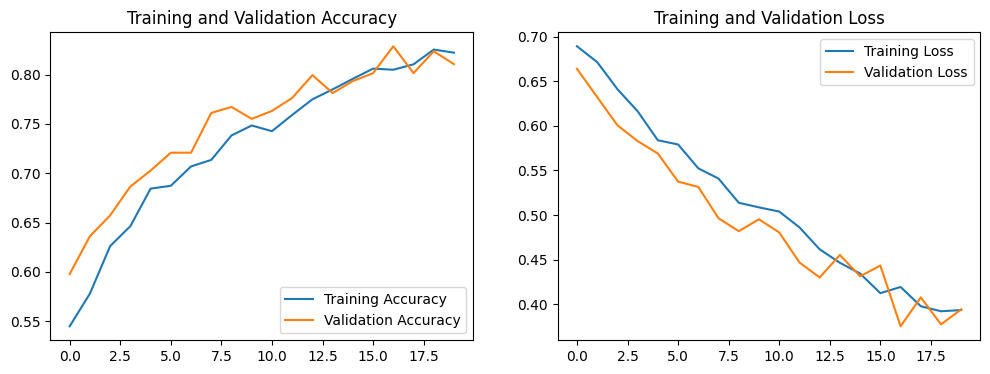

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()